In [37]:
import warnings
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory

import numpy as np

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()

DATA_DIR = Path("./data").resolve()
FOOD_11_DIR = DATA_DIR / "food-11"
TRAINING_DIR = FOOD_11_DIR / "training"
VALIDATION_DIR = FOOD_11_DIR / "validation"
EVALUATION_DIR = FOOD_11_DIR / "evaluation"
OUTPUT_DIR = Path("./output").resolve()
MODELS_DIR = OUTPUT_DIR / "models"
MODEL_BASELINE_FILE = MODELS_DIR / "model_baseline.h5"
MODEL_EFFICIENTNETB0_FILE = MODELS_DIR / "model_efficientnetb0.h5"
MODEL_EFFICIENTNETB3_FILE = MODELS_DIR / "model_efficientnetb3.h5"
MODEL_ENSEMBLE_FILE = MODELS_DIR / "model_ensemble.h5"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

### Phase 1 : Exploration et Préparation

#### 1.1 Chargement et Inspection

**Tâches :**

1. Charger Food-11 depuis le dossier local avec `image_dataset_from_directory`
2. Inspecter :
   - Nombre d'images par classe (variable, ~900-1500 par classe en train)
   - Distribution des tailles d'images
   - Range des valeurs pixels
   - Qualité des images (résolution, netteté)

3. Analyse statistique :
   - Distribution des dimensions (height, width)
   - Distribution RGB (couleur dominante)
   - Aspect ratio moyen
   - Images corrompues ou manquantes?

4. Visualiser quelques exemples de chaque classe (11 classes)

In [38]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    TRAINING_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=RANDOM_STATE,
    shuffle=True,
    label_mode="int",
)

val_ds = image_dataset_from_directory(
    VALIDATION_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int",
)

test_ds = image_dataset_from_directory(
    EVALUATION_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int",
)

Found 9866 files belonging to 11 classes.
Found 3430 files belonging to 11 classes.
Found 3347 files belonging to 11 classes.


In [3]:
labels = [
    "Bread",
    "Dairy production",
    "Desert",
    "Egg",
    "Fried food",
    "Meat",
    "Noodles-Pasta",
    "Rice",
    "Seafood",
    "Soup",
    "Vegetable-Fruit",
]


def get_class_distribution(dataset):
    all_labels = []
    for _, y in dataset:
        all_labels.extend(y.numpy())
    return [
        Counter(all_labels).get(i, 0) / len(all_labels) * 100
        for i in range(len(labels))
    ]


train_pct = get_class_distribution(train_ds)
val_pct = get_class_distribution(val_ds)
test_pct = get_class_distribution(test_ds)

counter_df = pd.DataFrame(
    {
        "label": labels * 3,
        "percentage": train_pct + val_pct + test_pct,
        "dataset": ["train"] * len(labels)
        + ["val"] * len(labels)
        + ["test"] * len(labels),
    }
)

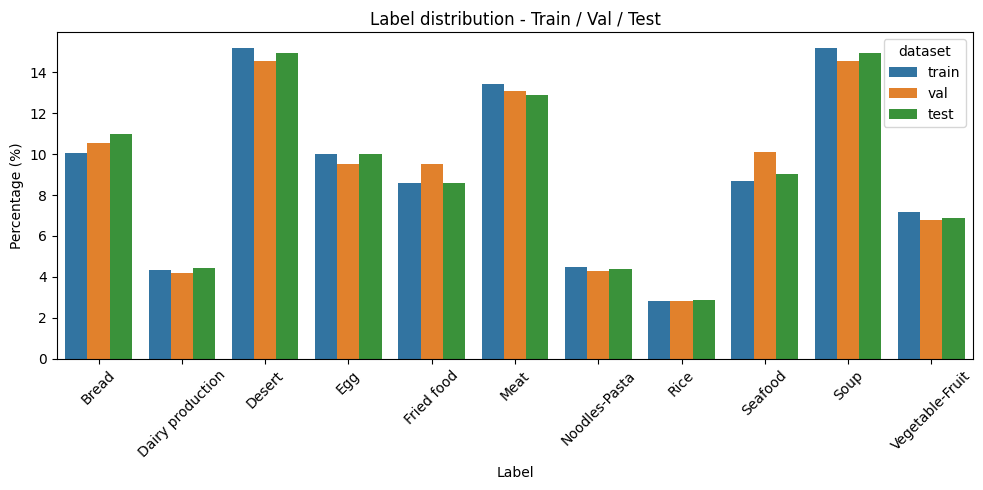

In [4]:
plt.figure(figsize=(10, 5))

sns.barplot(data=counter_df, x="label", y="percentage", hue="dataset")

plt.ylabel("Percentage (%)")
plt.xlabel("Label")
plt.title("Label distribution - Train / Val / Test")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
def get_images_sizes(directory):
    sizes = []
    labels = []
    for path in Path(directory).rglob("*"):
        if path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            with Image.open(path) as img:
                sizes.append(img.size)
                labels.append(path.parent.name)
    return sizes, labels


train_image_size, train_labels = get_images_sizes(TRAINING_DIR)
val_image_size, val_labels = get_images_sizes(VALIDATION_DIR)
test_image_size, test_labels = get_images_sizes(EVALUATION_DIR)


def build_df(sizes, labels, name):
    return pd.DataFrame(
        {
            "width": [s[0] for s in sizes],
            "height": [s[1] for s in sizes],
            "label": labels,
            "dataset": name,
        }
    )


images_sizes = pd.concat(
    [
        build_df(train_image_size, train_labels, "train"),
        build_df(val_image_size, val_labels, "val"),
        build_df(test_image_size, test_labels, "test"),
    ],
    ignore_index=True,
)

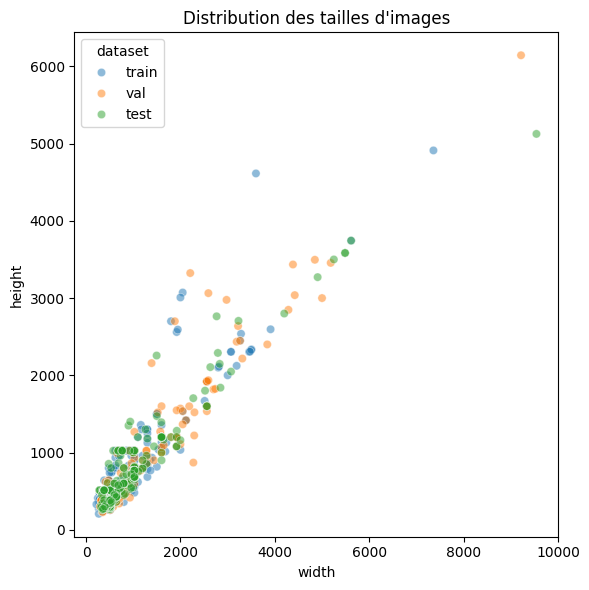

In [6]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=images_sizes, x="width", y="height", hue="dataset", alpha=0.5)
plt.title("Distribution des tailles d'images")
plt.tight_layout()
plt.show()

In [7]:
def get_pixels_ranges_values_rgb(dataset):
    min_vals = [float("inf")] * 3
    max_vals = [float("-inf")] * 3

    for x, _ in dataset:
        x = x.numpy()

        batch_min = x.min(axis=(0, 1, 2))
        batch_max = x.max(axis=(0, 1, 2))

        min_vals = [min(mv, bm) for mv, bm in zip(min_vals, batch_min)]
        max_vals = [max(mv, bm) for mv, bm in zip(max_vals, batch_max)]

    return min_vals, max_vals


train_min, train_max = get_pixels_ranges_values_rgb(train_ds)
val_min, val_max = get_pixels_ranges_values_rgb(val_ds)
test_min, test_max = get_pixels_ranges_values_rgb(test_ds)

pixels_ranges_values_rgb = pd.DataFrame(
    {
        "dataset": ["train"] * 3 + ["val"] * 3 + ["test"] * 3,
        "channel": ["R", "G", "B"] * 3,
        "min_pixel": train_min + val_min + test_min,
        "max_pixel": train_max + val_max + test_max,
    }
)

In [8]:
pixels_ranges_values_rgb.head(len(pixels_ranges_values_rgb))

,dataset,channel,min_pixel,max_pixel
0,train,R,0.0,255.0
1,train,G,0.0,255.0
2,train,B,0.0,255.0
3,val,R,0.0,255.0
4,val,G,0.0,255.0
5,val,B,0.0,255.0
6,test,R,0.0,255.0
7,test,G,0.0,255.0
8,test,B,0.0,255.0


In [9]:
images_sizes["resolution"] = images_sizes["width"] * images_sizes["height"]


def categorize_resolution(res):
    if res < 50_000:
        return "Très basse"
    elif res < 150_000:
        return "Basse"
    elif res < 400_000:
        return "Moyenne"
    else:
        return "Haute"


images_sizes["resolution_category"] = images_sizes["resolution"].apply(
    categorize_resolution
)

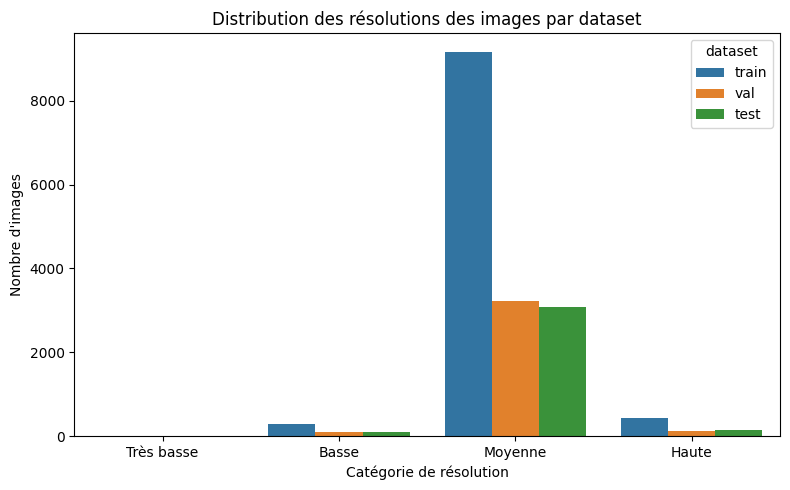

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=images_sizes,
    x="resolution_category",
    hue="dataset",
    order=["Très basse", "Basse", "Moyenne", "Haute"],
)

plt.ylabel("Nombre d'images")
plt.xlabel("Catégorie de résolution")
plt.title("Distribution des résolutions des images par dataset")

plt.tight_layout()
plt.show()

In [11]:
def measure_sharpness(image_path):
    img = cv2.imread(str(image_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    return laplacian.var()


def get_sharpness_dataset(directory):
    data = []

    for path in Path(directory).rglob("*"):
        if path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            label = path.parent.name
            sharpness = measure_sharpness(path)
            if sharpness is not None:
                data.append(
                    {
                        "dataset": Path(directory).name,
                        "label": label,
                        "sharpness": sharpness,
                    }
                )
    return pd.DataFrame(data)


train_sharp = get_sharpness_dataset(TRAINING_DIR)
val_sharp = get_sharpness_dataset(VALIDATION_DIR)
test_sharp = get_sharpness_dataset(EVALUATION_DIR)

df_sharp = pd.concat([train_sharp, val_sharp, test_sharp])


def categorize_sharpness_professional(value):
    if value < 50:
        return "Très floue"
    elif value < 150:
        return "Floue"
    elif value < 300:
        return "Moyennement nette"
    else:
        return "Très nette"


df_sharp["sharpness_category"] = df_sharp["sharpness"].apply(
    categorize_sharpness_professional
)

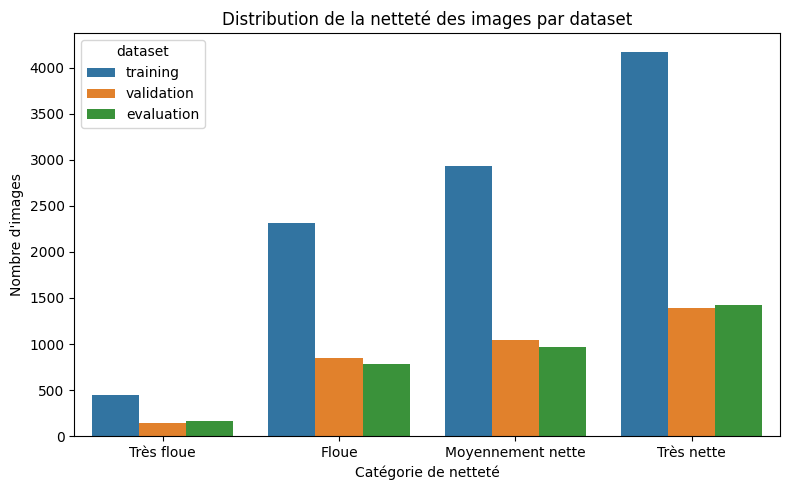

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_sharp,
    x="sharpness_category",
    hue="dataset",
    order=["Très floue", "Floue", "Moyennement nette", "Très nette"],
)
plt.title("Distribution de la netteté des images par dataset")
plt.xlabel("Catégorie de netteté")
plt.ylabel("Nombre d'images")

plt.tight_layout()
plt.show()

In [13]:
def get_mean_rgb_by_class(directory):
    data = []
    for path in Path(directory).rglob("*"):
        if path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            label = path.parent.name
            with Image.open(path) as img:
                img_array = np.array(img)
                if img_array.ndim == 2:
                    img_array = np.stack([img_array] * 3, axis=-1)
                mean_r = img_array[:, :, 0].mean()
                mean_g = img_array[:, :, 1].mean()
                mean_b = img_array[:, :, 2].mean()

                data.append(
                    {
                        "dataset": Path(directory).name,
                        "label": label,
                        "R": mean_r,
                        "G": mean_g,
                        "B": mean_b,
                    }
                )
    return pd.DataFrame(data)


train_rgb = get_mean_rgb_by_class(TRAINING_DIR)
val_rgb = get_mean_rgb_by_class(VALIDATION_DIR)
test_rgb = get_mean_rgb_by_class(EVALUATION_DIR)

df_rgb = pd.concat([train_rgb, val_rgb, test_rgb])

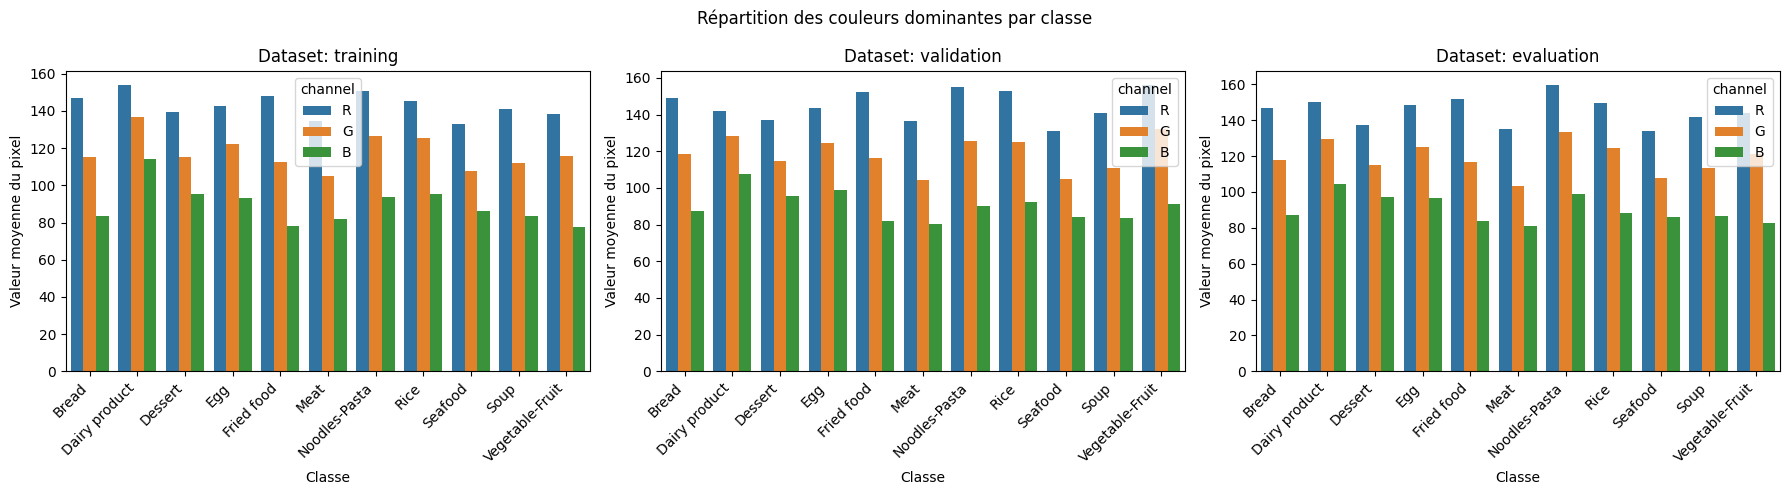

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for i, dataset in enumerate(df_rgb["dataset"].unique()):
    ax = axes[i]
    df_subset = df_rgb[df_rgb["dataset"] == dataset]

    df_class_mean = df_subset.groupby("label")[["R", "G", "B"]].mean().reset_index()
    df_long = df_class_mean.melt(
        id_vars="label", var_name="channel", value_name="mean_pixel"
    )

    sns.barplot(data=df_long, x="label", y="mean_pixel", hue="channel", ax=ax)
    ax.set_title(f"Dataset: {dataset}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_ylabel("Valeur moyenne du pixel")
    ax.set_xlabel("Classe")

plt.suptitle("Répartition des couleurs dominantes par classe")
plt.tight_layout()
plt.show()

In [15]:
images_sizes["aspect_ratio"] = images_sizes["width"] / images_sizes["height"]

aspect_ratio_mean_dataset = (
    images_sizes.groupby("dataset")["aspect_ratio"].mean().reset_index()
)
aspect_ratio_mean_dataset.rename(
    columns={"aspect_ratio": "aspect_ratio_mean"}, inplace=True
)
print("Aspect ratio moyen par dataset :")
print(aspect_ratio_mean_dataset)

Aspect ratio moyen par dataset :
  dataset  aspect_ratio_mean
0    test           1.084361
1   train           1.093445
2     val           1.081808


In [16]:
aspect_ratio_par_classe = (
    images_sizes.groupby(["dataset", "label"])["aspect_ratio"]
    .mean()
    .reset_index()
    .rename(columns={"aspect_ratio": "aspect_ratio_mean"})
)

print("Aspect ratio moyen par classe pour le dataset d'entraînement :")
print(aspect_ratio_par_classe[aspect_ratio_par_classe["dataset"] == "train"])

Aspect ratio moyen par classe pour le dataset d'entraînement :
   dataset            label  aspect_ratio_mean
11   train            Bread           1.085859
12   train    Dairy product           1.167990
13   train          Dessert           1.068868
14   train              Egg           1.065374
15   train       Fried food           1.060360
16   train             Meat           1.083211
17   train    Noodles-Pasta           1.114187
18   train             Rice           1.199024
19   train          Seafood           1.078581
20   train             Soup           1.055255
21   train  Vegetable-Fruit           1.252858


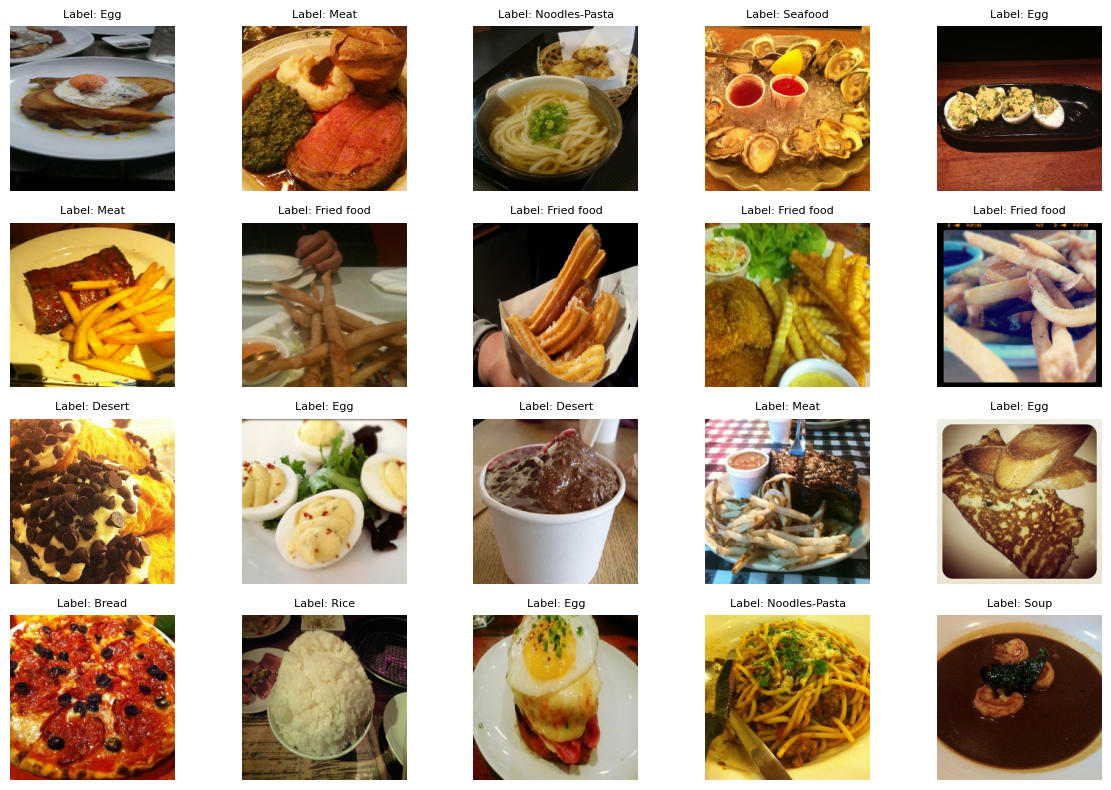

In [17]:
plt.figure(figsize=(12, 8))

num_images = 20
count = 0

for batch_x, batch_y in train_ds:
    for img, label in zip(batch_x, batch_y):
        plt.subplot(4, 5, count + 1)
        plt.imshow(img.numpy().astype("uint8"))  # convertir en uint8 pour imshow
        plt.title(f"Label: {labels[int(label)]}", fontsize=8)
        plt.axis("off")

        count += 1
        if count >= num_images:
            break
    if count >= num_images:
        break

plt.tight_layout()
plt.show()

#### 1.2 Stratégie de Préparation

**Décisions :**

1. **Taille cible** :
   - Option 1 : 224x224 (standard transfer learning)
   - Option 2 : 299x299 (InceptionV3, EfficientNet)
   - Option 3 : 384x384 (meilleure résolution, plus lent)

2. **Normalisation** :
   - ImageNet normalization (transfer learning)

3. **Data Augmentation** :
   - Rotation: ±15° (plats présentés à différents angles)
   - Zoom: ±20%
   - Brightness: ±15% (conditions d'éclairage variables)
   - Saturation: ±10% (qualité appareil photo)
   - Flip horizontal: activé

4. **Split validation** :
   - Créer validation set : 10% du train (7 575 images)
   - Train final : 68 175 images

In [39]:
def normalize_images(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, y


train_ds_normalized = (
    train_ds.map(normalize_images).cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
)
val_ds_normalized = val_ds.map(normalize_images).cache().prefetch(tf.data.AUTOTUNE)
test_ds_normalized = test_ds.map(normalize_images).cache().prefetch(tf.data.AUTOTUNE)

In [40]:
data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(0.15),
        layers.RandomSaturation(0.1),
        layers.RandomBrightness(0.15),
        layers.RandomFlip("horizontal"),
    ]
)

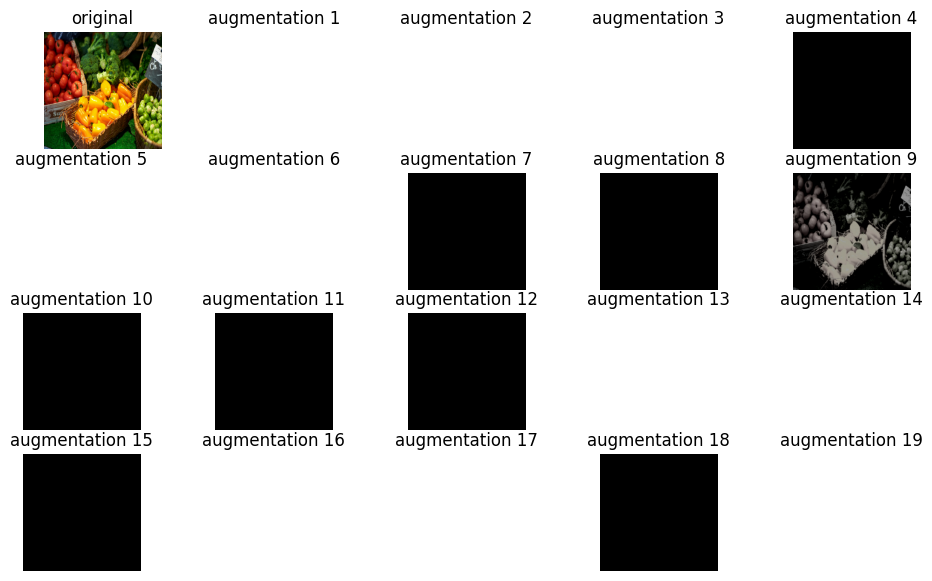

In [20]:
image, label = next(iter(train_ds.unbatch()))
image_processed, label = normalize_images(image, label)
image_processed_batch = tf.expand_dims(image_processed, 0)

plt.figure(figsize=(12, 7))

plt.subplot(4, 4, 1)
plt.imshow(image.numpy().astype("uint8"))
plt.title("original")
plt.axis("off")

for i in range(19):
    augmented_img = data_augmentation(image_processed_batch, training=True)
    plt.subplot(4, 5, i + 2)
    plt.imshow(tf.clip_by_value(augmented_img[0], 0, 1).numpy())
    plt.title(f"augmentation {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Phase 2 : Modélisation

#### 2.1 Architecture 1 : CNN Custom (Baseline)

**Objectif** : Établir une baseline avec CNN from scratch.

**Hyperparamètres :**

- Optimizer: Adam(lr=0.001)
- Batch size: 32
- Epochs: 50 (avec early stopping)
- Loss: sparse_categorical_crossentropy

In [66]:
def create_cnn_model(base_model=None, augmentation=False):
    model_layers = [layers.Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))]

    if augmentation:
        model_layers.extend(data_augmentation.layers)

    if base_model is None:
        model_layers.extend(
            [
                layers.Conv2D(32, 3, activation="relu"),
                layers.BatchNormalization(),
                layers.MaxPooling2D(2),
                layers.Conv2D(64, 3, activation="relu"),
                layers.BatchNormalization(),
                layers.MaxPooling2D(2),
                layers.Conv2D(128, 3, activation="relu"),
                layers.BatchNormalization(),
                layers.MaxPooling2D(2),
                layers.Flatten(),
            ]
        )
    else:
        model_layers.extend(
            [
                base_model,
                layers.GlobalAveragePooling2D(),
                layers.BatchNormalization(),
            ]
        )

    model_layers.extend(
        [
            layers.Dense(128, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.1),
            layers.Dense(11, activation="softmax"),
        ]
    )

    model = keras.Sequential(model_layers)

    return model


model_with_aug = create_cnn_model(augmentation=True)

model_with_aug.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True, verbose=1
)
reduce_lr_on_plateau = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", patience=3, factor=0.5, verbose=1
)
model_checkpoint_baseline = keras.callbacks.ModelCheckpoint(
    filepath=MODEL_BASELINE_FILE.as_posix(),
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)


history_with_aug = model_with_aug.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds,
    callbacks=[
        early_stopping,
        reduce_lr_on_plateau,
        # model_checkpoint_baseline,
    ],
    verbose=1,
)

Epoch 1/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 157s 504ms/step - accuracy: 0.2537 - loss: 2.2491 - val_accuracy: 0.0895 - val_loss: 5.5706 - learning_rate: 0.0010
Epoch 2/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 156s 505ms/step - accuracy: 0.3200 - loss: 1.9680 - val_accuracy: 0.2099 - val_loss: 2.5540 - learning_rate: 0.0010
Epoch 3/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 159s 513ms/step - accuracy: 0.3581 - loss: 1.8463 - val_accuracy: 0.1671 - val_loss: 4.0599 - learning_rate: 0.0010
Epoch 4/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 159s 515ms/step - accuracy: 0.4057 - loss: 1.7113 - val_accuracy: 0.1662 - val_loss: 3.8492 - learning_rate: 0.0010
Epoch 5/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 160s 518ms/step - accuracy: 0.4341 - loss: 1.6214 - val_accuracy: 0.3207 - val_loss: 2.1078 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.


#### 2.2 Architecture 2 : Transfer Learning - EfficientNetB0

**Objectif** : Utiliser un modèle pré-entraîné ImageNet.

Freeze base (10-15 epochs)

In [22]:
EfficientNetB0 = keras.applications.EfficientNetB0(
    input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3),
    include_top=False,
    weights="imagenet",
)

EfficientNetB0.trainable = False

model_with_EfficientNetB0 = create_cnn_model(
    base_model=EfficientNetB0, augmentation=True
)

model_with_EfficientNetB0.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model_checkpoint_EfficientNetB0 = keras.callbacks.ModelCheckpoint(
    filepath=MODEL_EFFICIENTNETB0_FILE.as_posix(),
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

history_with_EfficientNetB0 = model_with_EfficientNetB0.fit(
    train_ds,
    epochs=1,
    validation_data=val_ds,
    callbacks=[
        early_stopping,
        reduce_lr_on_plateau,
        # model_checkpoint_EfficientNetB0,
    ],
    verbose=1,
)

309/309 ━━━━━━━━━━━━━━━━━━━━ 91s 279ms/step - accuracy: 0.6667 - loss: 1.0551 - val_accuracy: 0.8117 - val_loss: 0.5811 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.


#### 2.3 Architecture 3 : Transfer Learning - EfficientNetB3

**Objectif** : Modèle plus profond pour meilleure performance.

In [24]:
EfficientNetB3 = keras.applications.EfficientNetB3(
    input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3),
    include_top=False,
    weights="imagenet",
)

EfficientNetB3.trainable = False

model_with_EfficientNetB3 = create_cnn_model(
    base_model=EfficientNetB3, augmentation=True
)

model_with_EfficientNetB3.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model_checkpoint_EfficientNetB3 = keras.callbacks.ModelCheckpoint(
    filepath=MODEL_EFFICIENTNETB3_FILE.as_posix(),
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

history_with_EfficientNetB3 = model_with_EfficientNetB3.fit(
    train_ds,
    epochs=1,
    validation_data=val_ds,
    callbacks=[
        early_stopping,
        reduce_lr_on_plateau,
        # model_checkpoint_EfficientNetB3,
    ],
    verbose=1,
)

309/309 ━━━━━━━━━━━━━━━━━━━━ 180s 557ms/step - accuracy: 0.6716 - loss: 1.0312 - val_accuracy: 0.8303 - val_loss: 0.5552 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.


#### 2.4 Architecture 4 : Ensemble (Bonus)

**Objectif** : Combiner plusieurs modèles pour boost performance.

In [48]:
def create_ensemble(*models, augmentation=False):
    if len(models) == 0:
        raise ValueError("Au moins un modèle est requis")

    inputs = layers.Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))

    x = inputs
    if augmentation:
        x = data_augmentation(x)

    features = []
    for model in models:
        y = model(x)
        y = layers.GlobalAveragePooling2D()(y)
        y = layers.BatchNormalization()(y)
        y = layers.Dense(128, activation="relu")(y)
        y = layers.BatchNormalization()(y)
        y = layers.Dropout(0.1)(y)
        y = layers.Dense(11, activation="softmax")(y)
        features.append(y)

    outputs = layers.Average()(features)

    return keras.Model(inputs, outputs)


model_ensemble = create_ensemble(EfficientNetB0, EfficientNetB3, augmentation=True)

model_ensemble.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model_checkpoint_ensemble = keras.callbacks.ModelCheckpoint(
    filepath=MODEL_ENSEMBLE_FILE.as_posix(),
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

history_ensemble = model_ensemble.fit(
    train_ds,
    epochs=1,
    validation_data=val_ds,
    callbacks=[
        early_stopping,
        reduce_lr_on_plateau,
        # model_checkpoint_ensemble,
    ],
    verbose=1,
)

309/309 ━━━━━━━━━━━━━━━━━━━━ 273s 844ms/step - accuracy: 0.7016 - loss: 0.9427 - val_accuracy: 0.8350 - val_loss: 0.5282 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.


#### 4.1 Métriques Globales

In [49]:
model_names = [
    "model_with_aug",
    "model_with_EfficientNetB0",
    "model_with_EfficientNetB3",
    "model_ensemble",
]

histories = [
    history_with_aug,
    history_with_EfficientNetB0,
    history_with_EfficientNetB3,
    history_ensemble,
]

metrics_list = []
for name, hist in zip(model_names, histories):
    val_acc = max(hist.history.get("val_accuracy", [0]))
    val_loss = min(hist.history.get("val_loss", [float("inf")]))

    metrics_list.append(
        {"Model": name, "Best Val Accuracy": val_acc, "Best Val Loss": val_loss}
    )

df_metrics = pd.DataFrame(metrics_list)
df_metrics = df_metrics.sort_values(by="Best Val Accuracy", ascending=False)
df_metrics

,Model,Best Val Accuracy,Best Val Loss
3,model_ensemble,0.834985,0.528168
2,model_with_EfficientNetB3,0.830321,0.555226
1,model_with_EfficientNetB0,0.811662,0.581129
0,model_with_aug,0.098251,4.217272


#### 4.2 Analyse des Erreurs

**Tâches :**

1. **Classes les plus faciles** (accuracy > 85%)

2. **Classes les plus difficiles** (accuracy < 60%)

3. **Matrice de confusion**

4. **Visualisation des erreurs** :
   - Afficher 20 images mal classifiées
   - Analyser pourquoi (occlusion, angle, similarité)

In [67]:
y_true = np.concatenate([y.numpy() for _, y in test_ds_normalized], axis=0)

y_pred_onehot = model_with_aug.predict(test_ds_normalized)
y_pred = np.argmax(y_pred_onehot, axis=1)

print("\nClassification report:")
print(classification_report(y_true, y_pred))

105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       368
           1       0.00      0.00      0.00       148
           2       0.00      0.00      0.00       500
           3       0.00      0.00      0.00       335
           4       0.00      0.00      0.00       287
           5       0.00      0.00      0.00       432
           6       0.00      0.00      0.00       147
           7       0.00      0.00      0.00        96
           8       0.00      0.00      0.00       303
           9       0.15      1.00      0.26       500
          10       0.00      0.00      0.00       231

    accuracy                           0.15      3347
   macro avg       0.01      0.09      0.02      3347
weighted avg       0.02      0.15      0.04      3347



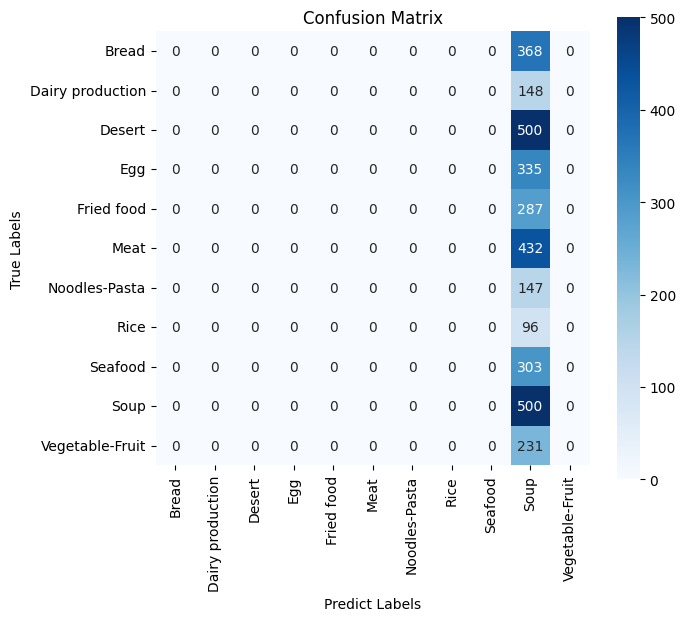

In [68]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", square=True)
plt.xlabel("Predict Labels")
plt.xticks(np.arange(0.5, len(labels) + 0.5, 1), labels, rotation=90)
plt.ylabel("True Labels")
plt.yticks(np.arange(0.5, len(labels) + 0.5, 1), labels, rotation=0)
plt.title("Confusion Matrix")
plt.show()

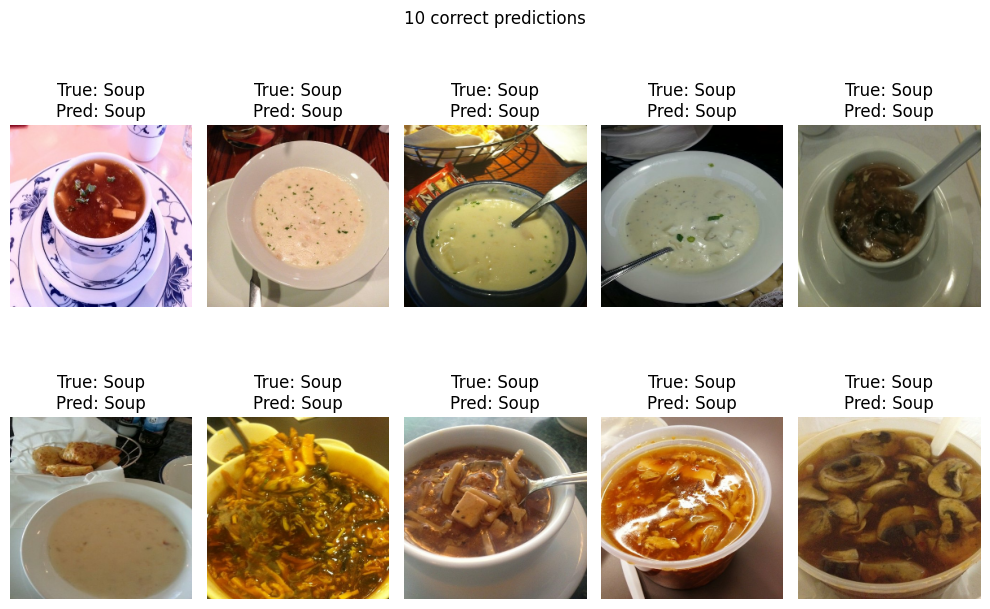

In [69]:
mask = np.where(y_true == y_pred)[0]

correct_images = []
correct_labels = []
correct_preds = []

for i, (x, y) in enumerate(test_ds_normalized.unbatch()):
    if i in mask:
        correct_images.append(x.numpy())
        correct_labels.append(int(y.numpy()))
        correct_preds.append(int(y_pred[i]))
    if len(correct_images) >= 10:
        break

plt.figure(figsize=(10, 7))
plt.suptitle("10 correct predictions")

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(tf.squeeze(correct_images[i]), cmap="gray")
    plt.title(f"True: {labels[correct_labels[i]]}\nPred: {labels[correct_preds[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

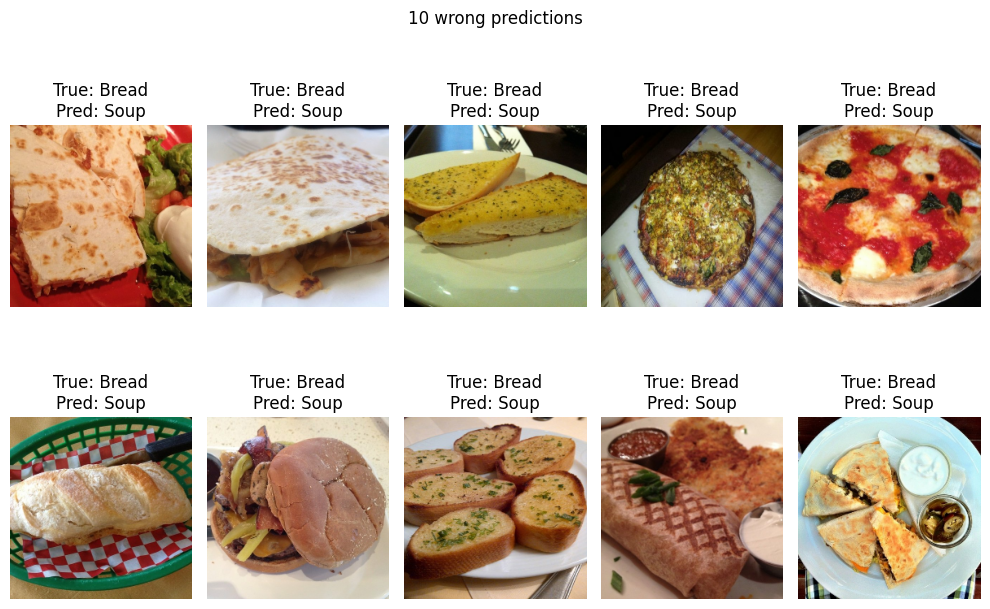

In [70]:
wrong_images = []
wrong_labels = []
wrong_preds = []

for i, (x, y) in enumerate(test_ds_normalized.unbatch()):
    if i not in mask:
        wrong_images.append(x.numpy())
        wrong_labels.append(int(y.numpy()))
        wrong_preds.append(int(y_pred[i]))
    if len(wrong_images) >= 10:
        break

plt.figure(figsize=(10, 7))
plt.suptitle("10 wrong predictions")

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(tf.squeeze(wrong_images[i]), cmap="gray")
    plt.title(f"True: {labels[wrong_labels[i]]}\nPred: {labels[wrong_preds[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Phase 5 : Interprétabilité

#### 5.1 Feature Maps Visualization

#### 5.2 GRAD-CAM

### Phase 6 : Déploiement

#### 6.1 Sauvegarde du Modèle

#### 6.2 Pipeline de Prédiction Réutilisable (Bonus)